<div style="background:linear-gradient(135deg,#4338CA 0%,#7C3AED 55%,#EC4899 100%);border-radius:18px;padding:28px 30px;margin:15px 0 22px 0;">
<p style="color:#FBCFE8;font-size:14px;font-weight:bold;letter-spacing:1.5px;margin:0 0 10px 0;">WEEK 6 · DEEP LEARNING · DAY 1</p>
<h1 style="color:#FFFFFF;font-size:31px;margin:0 0 9px 0;">From Patient Data to Neural Networks</h1>
<p style="color:#EDE9FE;font-size:16px;margin:0;">Understanding the building blocks before training a deeper model</p>
</div>
<div style="background:#FAF7FF;border:1px solid #E9D5FF;border-radius:15px;padding:20px 22px;margin:16px 0;">
<h2 style="color:#6D28D9;font-size:22px;margin:0 0 12px 0;">Where Does This Week Begin?</h2>
<p style="color:#374151;line-height:1.9;margin:0;">This week, I will explore whether a <b style="color:#DB2777;">neural network</b> can learn meaningful patterns from a <b style="color:#4F46E5;">clinical heart disease dataset</b>.</p>
<p style="color:#374151;line-height:1.9;margin:9px 0 0 0;">Before building a complex model, I need to understand the data, establish a <b style="color:#059669;">baseline</b>, and learn how <b style="color:#EA580C;">neurons, layers, weights, and biases</b> work together.</p>
</div>
<div style="background:#EFF6FF;border-left:5px solid #3B82F6;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#1E3A8A;line-height:1.8;margin:0;"><b>Today's question:</b> How can a neural network turn patient health indicators into a prediction?</p>
</div>

<div style="background:#FFF7ED;border:1px solid #FED7AA;border-radius:15px;padding:18px 21px;margin:18px 0;">
<h2 style="color:#C2410C;margin:0 0 12px 0;">What Will I Explore Today?</h2>
<p style="color:#374151;line-height:2;margin:0;">
<b style="color:#7C3AED;">01 — Dataset:</b> Understand the patient records, features, and target.<br>
<b style="color:#DB2777;">02 — Data Quality:</b> Check missing values, duplicates, and class balance.<br>
<b style="color:#2563EB;">03 — Baseline:</b> Train Logistic Regression as a reference model.<br>
<b style="color:#059669;">04 — The Neuron:</b> Understand inputs, weights, bias, and activation.<br>
<b style="color:#EA580C;">05 — Architecture:</b> Connect neural network layers to the project.
</p>
</div>

<div style="
    background:linear-gradient(135deg,#EEF2FF 0%,#FDF2F8 100%);
    border:1px solid #E9D5FF;
    border-radius:15px;
    padding:18px 21px;
    margin:20px 0;
">

<h2 style="color:#6D28D9;margin:0 0 12px 0;">
Sprint 1 Planning
</h2>

<p style="color:#374151;line-height:1.8;margin:0 0 10px 0;">
<b style="color:#2563EB;">Sprint Goal:</b>
Prepare the heart disease dataset and establish a trustworthy baseline that every later neural network must be compared against.
</p>

<p style="color:#374151;line-height:1.9;margin:0;">
<b style="color:#DB2777;">First Backlog Tasks:</b>
Finalize the dataset and target, complete a brief EDA, build a leakage-safe preprocessing workflow, train Logistic Regression, and record its evaluation metrics.
</p>

</div>

<div style="
    background:#FDF2F8;
    border-left:5px solid #EC4899;
    border-radius:13px;
    padding:17px 20px;
    margin:19px 0;
">

<h2 style="color:#BE185D;margin:0 0 10px 0;">
Why Consider Deep Learning?
</h2>

<p style="color:#374151;line-height:1.8;margin:0 0 9px 0;">

Deep learning is especially useful for complex or unstructured data, such as
<b style="color:#7C3AED;">images</b>,
<b style="color:#2563EB;">text</b>,
and
<b style="color:#EA580C;">audio</b>.

Neural networks can learn useful patterns directly through connected layers.

</p>

<p style="color:#374151;line-height:1.8;margin:0;">

However, this project uses a relatively small
<b style="color:#059669;">structured clinical dataset</b>.

A neural network is not guaranteed to outperform classical models, so its value must be judged by comparing it with the
<b style="color:#DB2777;">Logistic Regression baseline</b>.

</p>

</div>

<div style="
    background:#ECFDF5;
    border-left:5px solid #10B981;
    border-radius:12px;
    padding:15px 18px;
    margin:19px 0;
">

<h2 style="color:#047857;margin:0 0 7px 0;">
Hands-On Lab: From Patient Data to a Baseline Model
</h2>

<p style="color:#374151;line-height:1.8;margin:0;">
I will explore the dataset, prepare the patient features, train a baseline classifier, and connect the results to neural network fundamentals.
</p>

</div>

<div style="background:#F5F3FF;border-left:5px solid #7C3AED;border-radius:12px;padding:15px 19px;margin:20px 0;">
<h2 style="color:#6D28D9;margin:0 0 7px 0;">1. Preparing the Working Environment</h2>
<p style="color:#374151;margin:0;line-height:1.7;">Import the tools needed to explore the dataset, prepare its features, build a baseline, and understand how a neuron works.</p>
</div>

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

<div style="background:#FFFDF0;border:1px solid #FDE68A;border-radius:14px;padding:17px 20px;margin:20px 0;">
<h2 style="color:#B45309;margin:0 0 9px 0;">2. Dataset Selection</h2>
<p style="color:#374151;line-height:1.8;margin:0;">I selected the <b style="color:#7C3AED;">Heart Failure Prediction Dataset</b>, which combines clinical records from <b style="color:#2563EB;">five heart disease datasets</b>.</p>
</div>
<div style="background:#ECFDF5;border-left:5px solid #10B981;border-radius:11px;padding:14px 17px;margin:13px 0;">
<p style="color:#374151;line-height:1.8;margin:0;">The final dataset contains <b style="color:#047857;">918 patient records</b>, <b style="color:#7C3AED;">11 clinical features</b>, and one binary target: <b style="color:#BE123C;">HeartDisease</b>.</p>
</div>
<div style="background:#EFF6FF;border-left:5px solid #3B82F6;border-radius:11px;padding:14px 17px;margin:13px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#1D4ED8;"><div style="
    background:#EFF6FF;
    border-left:5px solid #3B82F6;
    border-radius:11px;
    padding:14px 17px;
    margin:13px 0;
">

<p style="color:#374151;line-height:1.8;margin:0;">

<b style="color:#1D4ED8;">Research note:</b>
The dataset combines records from five heart disease datasets.

Although its Kaggle title includes
<b style="color:#DB2777;">Heart Failure</b>,
the actual target,
<b style="color:#7C3AED;">HeartDisease</b>,
indicates whether heart disease is present or absent.

</p>

</div>
</div>
<p><a href="https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction">Dataset source on Kaggle</a></p>

In [10]:
data_path = "heart.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


<div style="background:#FDF2F8;border-left:5px solid #EC4899;border-radius:12px;padding:15px 18px;margin:18px 0;">
<h2 style="color:#BE185D;margin:0 0 7px 0;">3. What Information Does the Dataset Contain?</h2>
<p style="color:#374151;line-height:1.7;margin:0;">Before analyzing the data, I need to identify the clinical features and locate the prediction target.</p>
</div>

In [11]:
print("Dataset columns:")

df.columns.tolist()

Dataset columns:


['Age',
 'Sex',
 'ChestPainType',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'RestingECG',
 'MaxHR',
 'ExerciseAngina',
 'Oldpeak',
 'ST_Slope',
 'HeartDisease']

<div style="background:#F0F9FF;border:1px solid #BAE6FD;border-radius:14px;padding:17px 20px;margin:18px 0;">
<h2 style="color:#0369A1;margin:0 0 12px 0;">Understanding the Clinical Features</h2>
<p style="color:#374151;line-height:2;margin:0;">
<b style="color:#DB2777;">Target:</b> HeartDisease<br>
<b style="color:#7C3AED;">Patient information:</b> Age, Sex<br>
<b style="color:#059669;">Clinical measurements:</b> RestingBP, Cholesterol, FastingBS, MaxHR<br>
<b style="color:#2563EB;">Symptoms and examination:</b> ChestPainType, ExerciseAngina, RestingECG<br>
<b style="color:#EA580C;">Exercise-related indicators:</b> Oldpeak, ST_Slope
</p>
</div>

<div style="background:#FFF1F2;border-left:5px solid #F43F5E;border-radius:12px;padding:15px 18px;margin:19px 0;">
<h2 style="color:#BE123C;margin:0 0 7px 0;">4. Checking Data Quality</h2>
<p style="color:#374151;line-height:1.7;margin:0;">Before building any model, I need to check whether the dataset contains missing values or repeated records.</p>
</div>

In [12]:
quality_check = pd.DataFrame({
    "Check": [
        "Missing values",
        "Duplicate rows"
    ],
    "Count": [
        df.isna().sum().sum(),
        df.duplicated().sum()
    ]
})

quality_check

,Check,Count
0,Missing values,0
1,Duplicate rows,0


<div style="background:#F5F3FF;border-left:5px solid #8B5CF6;border-radius:12px;padding:15px 18px;margin:19px 0;">
<h2 style="color:#6D28D9;margin:0 0 7px 0;">5. Is the Target Balanced?</h2>
<p style="color:#374151;line-height:1.7;margin:0;">I will compare the number of patients with and without heart disease to check whether the classes are reasonably balanced.</p>
</div>

In [13]:
target_counts = df["HeartDisease"].value_counts().sort_index()

target_distribution = pd.DataFrame({
    "Patients": target_counts,
    "Percentage": (
        target_counts / len(df) * 100
    ).round(2)
})

target_distribution.index = [
    "No Heart Disease",
    "Heart Disease"
]

target_distribution

,Patients,Percentage
No Heart Disease,410,44.66
Heart Disease,508,55.34


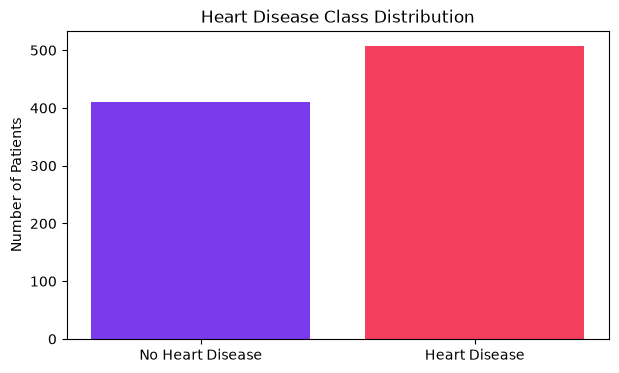

In [14]:
plt.figure(figsize=(7, 4))

plt.bar(
    target_distribution.index,
    target_distribution["Patients"],
    color=["#7C3AED", "#F43F5E"]
)

plt.title("Heart Disease Class Distribution")
plt.ylabel("Number of Patients")

plt.show()

<div style="
    background:#ECFDF5;
    border-left:5px solid #10B981;
    border-radius:11px;
    padding:14px 17px;
    margin:14px 0;
">

<p style="color:#374151;line-height:1.8;margin:0;">

<b style="color:#047857;">Observation:</b>
The dataset contains
<b style="color:#7C3AED;">410 patients without heart disease</b>
and
<b style="color:#DB2777;">508 patients with heart disease</b>.

The two classes are reasonably balanced, so the model is less likely to favor one group simply because it appears more often.

</p>

</div>

<div style="
    background:#FFF7ED;
    border-left:5px solid #F97316;
    border-radius:12px;
    padding:15px 18px;
    margin:19px 0;
">

<h2 style="color:#C2410C;margin:0 0 7px 0;">
6. Are All Clinical Values Realistic?
</h2>

<p style="color:#374151;line-height:1.7;margin:0;">
A dataset can contain no missing values and still include measurements that do not make medical sense.
</p>

</div>

In [15]:
clinical_checks = pd.DataFrame({
    "Feature": [
        "Cholesterol",
        "RestingBP"
    ],
    "Zero Values": [
        (df["Cholesterol"] == 0).sum(),
        (df["RestingBP"] == 0).sum()
    ]
})

clinical_checks

,Feature,Zero Values
0,Cholesterol,172
1,RestingBP,1


<div style="
    background:#FFFBEB;
    border-left:5px solid #F59E0B;
    border-radius:11px;
    padding:14px 17px;
    margin:14px 0;
">

<p style="color:#374151;line-height:1.8;margin:0;">

<b style="color:#B45309;">Observation:</b>
Although the dataset contains no recorded missing values,
<b style="color:#BE123C;">172 cholesterol measurements</b>
and
<b style="color:#7C3AED;">one resting blood pressure measurement</b>
are equal to zero.

Since these values are not clinically realistic, I will treat them as missing measurements instead of valid patient information.

</p>

</div>

In [16]:
df[["Cholesterol", "RestingBP"]] = (
    df[["Cholesterol", "RestingBP"]]
    .replace(0, np.nan)
)

df[["Cholesterol", "RestingBP"]].isna().sum()

Cholesterol    172
RestingBP        1
dtype: int64

<div style="
    background:#EEF2FF;
    border-left:5px solid #4F46E5;
    border-radius:12px;
    padding:15px 18px;
    margin:19px 0;
">

<h2 style="color:#4338CA;margin:0 0 7px 0;">
7. Preparing the Training and Testing Data
</h2>

<p style="color:#374151;line-height:1.7;margin:0;">
I will separate the patient features from the target, then keep part of the data hidden for final evaluation.
</p>

</div>

In [18]:
X = df.drop(columns="HeartDisease")
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Training positive rate:", round(y_train.mean(), 3))
print("Testing positive rate:", round(y_test.mean(), 3))

Training shape: (734, 11)
Testing shape: (184, 11)
Training positive rate: 0.553
Testing positive rate: 0.554


<div style="
    background:#ECFDF5;
    border-left:5px solid #10B981;
    border-radius:11px;
    padding:14px 17px;
    margin:14px 0;
">

<p style="color:#374151;line-height:1.8;margin:0;">

<b style="color:#047857;">Observation:</b>
The dataset was divided into
<b style="color:#7C3AED;">734 training records</b>
and
<b style="color:#DB2777;">184 testing records</b>.

The heart disease proportion remains almost identical in both sets:
<b style="color:#2563EB;">55.3%</b>
for training and
<b style="color:#2563EB;">55.4%</b>
for testing.

</p>

</div>

<div style="
    background:#FDF2F8;
    border-left:5px solid #EC4899;
    border-radius:12px;
    padding:15px 18px;
    margin:19px 0;
">

<h2 style="color:#BE185D;margin:0 0 7px 0;">
8. Preparing Different Feature Types
</h2>

<p style="color:#374151;line-height:1.7;margin:0;">
Numerical measurements and categorical values cannot be processed in the same way, so I will separate them before building the baseline.
</p>

</div>

In [19]:
numerical_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

categorical_features = [
    "Sex",
    "ChestPainType",
    "FastingBS",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
Categorical features: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


<div style="
    background:#EFF6FF;
    border-left:5px solid #3B82F6;
    border-radius:12px;
    padding:15px 18px;
    margin:19px 0;
">

<h2 style="color:#1D4ED8;margin:0 0 7px 0;">
9. Building the Preprocessing Workflow
</h2>

<p style="color:#374151;line-height:1.8;margin:0;">
Numerical features need missing-value treatment and scaling, while categorical features must be converted into a format the model can understand.
</p>

</div>

In [20]:
from sklearn.impute import SimpleImputer

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

<div style="
    background:#F5F3FF;
    border-left:5px solid #8B5CF6;
    border-radius:12px;
    padding:15px 18px;
    margin:19px 0;
">

<h2 style="color:#6D28D9;margin:0 0 7px 0;">
10. Building a Baseline Model
</h2>

<p style="color:#374151;line-height:1.8;margin:0;">
Before exploring neural networks, I will train a
<b style="color:#DB2777;">Logistic Regression</b>
model to establish a clear performance reference.
</p>

</div>

In [21]:
baseline_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully.")

Baseline model trained successfully.


<div style="
    background:#ECFDF5;
    border-left:5px solid #10B981;
    border-radius:12px;
    padding:15px 18px;
    margin:19px 0;
">

<h2 style="color:#047857;margin:0 0 7px 0;">
11. Evaluating the Baseline Model
</h2>

<p style="color:#374151;line-height:1.8;margin:0;">
I will evaluate the model on unseen patients using
<b style="color:#7C3AED;">Accuracy</b>,
<b style="color:#DB2777;">Precision</b>,
<b style="color:#2563EB;">Recall</b>,
and
<b style="color:#EA580C;">F1-score</b>.
</p>

</div>

In [22]:
baseline_predictions = baseline_model.predict(X_test)

baseline_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Score": [
        accuracy_score(y_test, baseline_predictions),
        precision_score(y_test, baseline_predictions),
        recall_score(y_test, baseline_predictions),
        f1_score(y_test, baseline_predictions)
    ]
})

baseline_results["Score"] = baseline_results["Score"].round(3)

baseline_results

,Metric,Score
0,Accuracy,0.886
1,Precision,0.886
2,Recall,0.912
3,F1-score,0.899


<div style="
    background:#ECFDF5;
    border-left:5px solid #10B981;
    border-radius:12px;
    padding:15px 18px;
    margin:16px 0;
">

<p style="color:#374151;line-height:1.9;margin:0;">

<b style="color:#047857;">Observation:</b>
The baseline model achieved
<b style="color:#7C3AED;">88.6% accuracy</b>
and an
<b style="color:#DB2777;">F1-score of 0.899</b>.

Its
<b style="color:#2563EB;">91.2% recall</b>
shows that it identified most patients with heart disease.

These results provide a strong reference for evaluating whether a neural network can offer a meaningful improvement.

</p>

</div>

<div style="
    background:#FFF7ED;
    border:1px solid #FED7AA;
    border-radius:13px;
    padding:16px 19px;
    margin:18px 0;
">

<h2 style="color:#C2410C;margin:0 0 9px 0;">
The Baseline to Beat
</h2>

<p style="color:#374151;line-height:1.9;margin:0;">

The Logistic Regression baseline achieved an
<b style="color:#7C3AED;">F1-score of 0.899</b>
and a
<b style="color:#DB2777;">recall of 0.912</b>.

Any later neural network should be compared against these results using the same evaluation setup.

A higher score is useful only if the model also continues to identify patients with heart disease reliably.

</p>

</div>

<div style="
    background:#FFF7ED;
    border-left:5px solid #F97316;
    border-radius:12px;
    padding:15px 18px;
    margin:19px 0;
">

<h2 style="color:#C2410C;margin:0 0 7px 0;">
12. Understanding the Model's Errors
</h2>

<p style="color:#374151;line-height:1.8;margin:0;">
A confusion matrix shows which patients were classified correctly and which heart disease cases the model failed to detect.
</p>

</div>

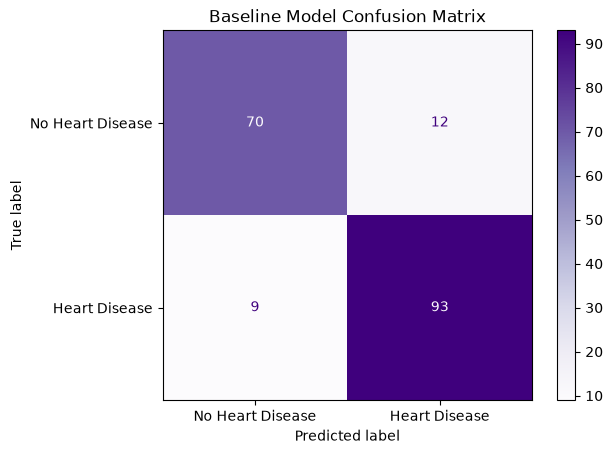

In [23]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    baseline_predictions,
    display_labels=[
        "No Heart Disease",
        "Heart Disease"
    ],
    cmap="Purples"
)

plt.title("Baseline Model Confusion Matrix")
plt.show()

<div style="
    background:#FFF1F2;
    border-left:5px solid #F43F5E;
    border-radius:12px;
    padding:15px 18px;
    margin:16px 0;
">

<p style="color:#374151;line-height:1.9;margin:0;">

<b style="color:#BE123C;">Observation:</b>
The model correctly identified
<b style="color:#7C3AED;">93 patients with heart disease</b>
and
<b style="color:#059669;">70 patients without heart disease</b>.

However,
<b style="color:#EA580C;">12 healthy patients</b>
were incorrectly classified as having heart disease, while
<b style="color:#DC2626;">9 actual heart disease cases</b>
were missed.

These missed cases are especially important because false negatives may delay further medical assessment.

</p>

</div>

<div style="
    background:linear-gradient(135deg,#EEF2FF 0%,#FDF2F8 100%);
    border-left:5px solid #8B5CF6;
    border-radius:14px;
    padding:17px 20px;
    margin:22px 0;
">

<h2 style="color:#6D28D9;margin:0 0 9px 0;">
13. What Happens Inside a Neuron?
</h2>

<p style="color:#374151;line-height:1.8;margin:0;">
A neuron receives patient features as
<b style="color:#2563EB;">inputs</b>,
multiplies them by learned
<b style="color:#DB2777;">weights</b>,
adds a
<b style="color:#EA580C;">bias</b>,
and applies an
<b style="color:#059669;">activation function</b>
to produce an output.
</p>

</div>

### The Neuron Equation

$$
z = x_1w_1 + x_2w_2 + x_3w_3 + b
$$

$$
\text{Output} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

<div style="
    background:#FFF7ED;
    border-left:5px solid #F97316;
    border-radius:12px;
    padding:15px 18px;
    margin:19px 0;
">

<h2 style="color:#C2410C;margin:0 0 7px 0;">
14. A Simple Neuron Example
</h2>

<p style="color:#374151;line-height:1.8;margin:0;">
This example uses illustrative inputs and weights to show how a neuron calculates its output.
</p>

</div>

In [24]:
patient_inputs = np.array([0.8, -0.4, 1.2])

weights = np.array([0.6, -0.3, 0.9])

bias = -0.2

weighted_sum = np.dot(patient_inputs, weights) + bias

neuron_output = 1 / (1 + np.exp(-weighted_sum))

print("Weighted sum:", round(weighted_sum, 3))
print("Neuron output:", round(neuron_output, 3))

Weighted sum: 1.48
Neuron output: 0.815


<div style="
    background:#ECFDF5;
    border-left:5px solid #10B981;
    border-radius:12px;
    padding:15px 18px;
    margin:16px 0;
">

<p style="color:#374151;line-height:1.9;margin:0;">

<b style="color:#047857;">Observation:</b>
The neuron produced a
<b style="color:#7C3AED;">weighted sum of 1.48</b>.

After applying the
<b style="color:#DB2777;">Sigmoid activation</b>,
the result became
<b style="color:#2563EB;">0.815</b>.

This illustrates how input values can be transformed into a score between zero and one.

</p>

</div>

<div style="
    background:#EFF6FF;
    border-left:5px solid #3B82F6;
    border-radius:12px;
    padding:15px 18px;
    margin:18px 0;
">

<h2 style="color:#1D4ED8;margin:0 0 8px 0;">
How Does This Connect to Logistic Regression?
</h2>

<p style="color:#374151;line-height:1.8;margin:0;">
Logistic Regression follows the same basic idea as a single output neuron:
it combines the inputs using learned
<b style="color:#7C3AED;">weights</b>,
adds a
<b style="color:#EA580C;">bias</b>,
and applies the
<b style="color:#DB2777;">Sigmoid function</b>.

A neural network extends this idea by adding hidden layers that can learn more complex relationships.

</p>

</div>

<div style="
    background:#EFF6FF;
    border-left:5px solid #3B82F6;
    border-radius:13px;
    padding:16px 19px;
    margin:18px 0;
">

<h2 style="color:#1D4ED8;margin:0 0 10px 0;">
What Does the Network Actually Learn?
</h2>

<p style="color:#374151;line-height:1.9;margin:0;">

A neural network starts with initial
<b style="color:#DB2777;">weights</b>
and
<b style="color:#EA580C;">biases</b>.

During training, it adjusts these values to reduce prediction errors.

The
<b style="color:#7C3AED;">weights</b>
control how strongly inputs influence a neuron, while the
<b style="color:#059669;">bias</b>
helps adjust its output.

Together, weights and biases are the model's
<b style="color:#2563EB;">learned parameters</b>.

</p>

</div>

<div style="
    background:#FDF2F8;
    border-left:5px solid #EC4899;
    border-radius:12px;
    padding:15px 18px;
    margin:19px 0;
">

<h2 style="color:#BE185D;margin:0 0 7px 0;">
15. How Many Inputs Will the Network Receive?
</h2>

<p style="color:#374151;line-height:1.8;margin:0;">
The neural network receives the processed features, not the original dataset columns directly.
Categorical encoding can increase the number of inputs.
</p>

</div>

In [25]:
processed_features = (
    baseline_model
    .named_steps["preprocessing"]
    .get_feature_names_out()
)

print("Original features:", X_train.shape[1])
print("Processed features:", len(processed_features))

Original features: 11
Processed features: 21


<div style="
    background:linear-gradient(135deg,#EEF2FF 0%,#FDF2F8 100%);
    border-left:5px solid #8B5CF6;
    border-radius:14px;
    padding:17px 20px;
    margin:20px 0;
">

<h2 style="color:#6D28D9;margin:0 0 10px 0;">
16. What Could the Neural Network Look Like?
</h2>

<p style="color:#374151;line-height:1.9;margin:0;">

<b style="color:#2563EB;">Input layer:</b>
21 processed patient features.

<br>

<b style="color:#DB2777;">First hidden layer:</b>
16 neurons to learn relationships between patient indicators.

<br>

<b style="color:#EA580C;">Second hidden layer:</b>
8 neurons to refine the learned patterns.

<br>

<b style="color:#059669;">Output layer:</b>
1 neuron to estimate the probability of heart disease.

</p>

</div>

<div style="
    background:#FFFFFF;
    border:1px solid #E9D5FF;
    border-radius:14px;
    padding:20px;
    margin:18px 0;
    text-align:center;
">

<h3 style="color:#6D28D9;margin:0 0 15px 0;">
How a Neural Network Is Organized
</h3>

<img src="Layers.png" width="650">

<p style="color:#374151;line-height:1.8;margin:15px 0 7px 0;">

<b style="color:#2563EB;">Input Layer</b>
→
<b style="color:#DB2777;">Hidden Layers</b>
→
<b style="color:#059669;">Output Layer</b>

</p>

<p style="color:#6B7280;font-size:13px;margin:0;">
Source: Google for Developers
</p>

</div>

<div style="
    background:#F5F3FF;
    border-left:5px solid #8B5CF6;
    border-radius:12px;
    padding:15px 18px;
    margin:15px 0;
">

<p style="color:#374151;line-height:1.9;margin:0;">

<b style="color:#6D28D9;">How to Read the Diagram:</b>

The
<b style="color:#2563EB;">input layer</b>
receives the processed patient features.

The
<b style="color:#DB2777;">hidden layers</b>
combine these features and learn patterns between them.

Finally, the
<b style="color:#059669;">output layer</b>
produces the predicted probability of heart disease.

Each connection represents a
<b style="color:#EA580C;">weight</b>
that the network adjusts during training.

</p>

</div>

<div style="
    background:#FFF7ED;
    border:1px solid #FED7AA;
    border-radius:14px;
    padding:17px 20px;
    margin:20px 0;
">

<h2 style="color:#C2410C;margin:0 0 12px 0;">
Hands-On Lab: Sprint 1 Kickoff & Baseline
</h2>

<p style="color:#374151;line-height:2;margin:0;">

<b style="color:#7C3AED;">Step 1 — Sprint Planning:</b>
Confirmed the sprint goal and first backlog tasks.
<br>

<b style="color:#DB2777;">Step 2 — Dataset and EDA:</b>
Selected the dataset, reviewed its quality, and explored the target distribution.
<br>

<b style="color:#2563EB;">Step 3 — Baseline Model:</b>
Trained Logistic Regression and recorded the evaluation metrics.
<br>

<b style="color:#EA580C;">Step 4 — GitHub Workflow:</b>
Commit the notebook to a feature branch and open a draft pull request.
<br>

<b style="color:#059669;">Step 5 — Baseline to Beat:</b>
F1-score: 0.899 | Recall: 0.912.

</p>

</div>

<div style="
    background:linear-gradient(135deg,#EEF2FF 0%,#FDF2F8 100%);
    border:1px solid #E9D5FF;
    border-radius:15px;
    padding:18px 21px;
    margin:20px 0;
">

<h2 style="color:#6D28D9;margin:0 0 12px 0;">
Day 1 Summary
</h2>

<p style="color:#374151;line-height:1.9;margin:0;">

Today, I explored
<b style="color:#2563EB;">918 patient records</b>,
identified hidden missing measurements, and prepared the data using appropriate preprocessing.

The
<b style="color:#DB2777;">Logistic Regression baseline</b>
achieved
<b style="color:#059669;">88.6% accuracy</b>
and
<b style="color:#7C3AED;">91.2% recall</b>.

I also examined how a neuron combines inputs, weights, bias, and activation, then outlined a possible neural network architecture:

<b style="color:#EA580C;">21 → 16 → 8 → 1</b>.

</p>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #E2E8F0;
    border-radius:14px;
    padding:17px 20px;
    margin:20px 0;
">

<h2 style="color:#334155;margin:0 0 12px 0;">
References
</h2>

<p style="line-height:2;margin:0;">

<a href="https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction">
Heart Failure Prediction Dataset — Kaggle
</a>

<br>

<a href="https://developers.google.com/machine-learning/crash-course/neural-networks/nodes-hidden-layers">
Neural Networks: Nodes and Hidden Layers — Google
</a>

<br>

<a href="https://scikit-learn.org/stable/modules/compose.html">
Pipelines and ColumnTransformer — Scikit-learn
</a>

<br>

<a href="https://www.deeplearningbook.org/contents/mlp.html">
Deep Feedforward Networks — Deep Learning Book
</a>

</p>

</div>